# Measuring Customer Delight — Exploratory Data Analysis

**Research question: did the digital fragrance advisor cause an increase in US fragrance
performance?**

A before-and-after comparison cannot answer this. The advisor launched in the United
States in April 2026, but so did other things — and the US has its own seasonal pattern.
Any of those could produce the same post-launch rise. To attribute the change to the
feature we need a **counterfactual**: a market that shows what the US would plausibly
have done without it.

This notebook is self-contained. It recomputes every finding from
`data/market_week_data.csv` rather than citing the subtask notebooks, so it can be read
and re-run on its own. The working detail behind each section lives in
[`eda_tasks/`](eda_tasks).

| Section | Question |
|---|---|
| 1 | What is in the data, and can we trust it? (findings A–D) |
| 2 | What happened to revenue per session over time? (finding E) |
| 3 | What else was happening around launch? (finding F) |
| 4 | Which market best approximates the untreated US? |
| 5 | Conclusion |

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "data" / "market_week_data.csv").exists())
sys.path.append(str(ROOT / "src"))

from eda_viz import load_panel, launch_week, plot_rps_all_markets, plot_rps_pairwise

FIGDIR = ROOT / "figures" / "eda"
FIGDIR.mkdir(parents=True, exist_ok=True)

df = load_panel()
PILOT = "United States"
METRIC = "revenue_per_session"
LAUNCH = launch_week(df)
CONTROLS = sorted(m for m in df["market"].unique() if m != PILOT)

print(f"{len(df):,} rows x {df.shape[1]} columns")
print(f"advisor live in {PILOT} from {LAUNCH:%Y-%m-%d}")

728 rows x 16 columns
advisor live in United States from 2026-04-06


---
## 1. What is in the data, and can we trust it?

Findings A–D. Each is recomputed below rather than asserted.

### A. Markets and date ranges

In [2]:
coverage = (df.groupby("market")["week_start"]
              .agg(first="min", last="max", weeks="count")
              .sort_index())
print(f"{df['market'].nunique()} markets, {df['week_index'].nunique()} distinct weeks")
print(f"panel spans {df['week_start'].min():%Y-%m-%d} to {df['week_start'].max():%Y-%m-%d}")
print(f"every market covers the identical range: "
      f"{coverage['first'].nunique() == 1 and coverage['last'].nunique() == 1}")
coverage

7 markets, 104 distinct weeks
panel spans 2025-01-06 to 2026-12-28
every market covers the identical range: True


,first,last,weeks
market,,,
Australia,2025-01-06,2026-12-28,104
Canada,2025-01-06,2026-12-28,104
France,2025-01-06,2026-12-28,104
Germany,2025-01-06,2026-12-28,104
Japan,2025-01-06,2026-12-28,104
United Kingdom,2025-01-06,2026-12-28,104
United States,2025-01-06,2026-12-28,104


### B. Frequency and completeness

In [3]:
gaps = {m: set(g["week_start"].sort_values().diff().dropna().dt.days)
        for m, g in df.groupby("market")}
grid = df.pivot_table(index="week_index", columns="market",
                      values=METRIC, aggfunc="count")

checks_b = pd.DataFrame([
    ("Spacing between weeks",      sorted(set().union(*gaps.values())), "[7] = strictly weekly"),
    ("Weekday of week_start",      df["week_start"].dt.day_name().unique().tolist(), "all Monday"),
    ("Rows per market",            sorted(df.groupby("market").size().unique()), "104 each"),
    ("Total rows",                 len(df), "728 = 7 x 104"),
    ("Missing values (all cols)",  int(df.isna().sum().sum()), "0"),
    ("Duplicate market-weeks",     int(df.duplicated(["market", "week_index"]).sum()), "0"),
    ("Panel cells with != 1 obs",  int((grid != 1).sum().sum()), "0 = balanced"),
    ("week_index -> week_start",   int(df.groupby("week_index")["week_start"].nunique().max()), "1 = consistent"),
], columns=["check", "value", "expected"])
checks_b

,check,value,expected
0,Spacing between weeks,[7],[7] = strictly weekly
1,Weekday of week_start,[Monday],all Monday
2,Rows per market,[104],104 each
3,Total rows,728,728 = 7 x 104
4,Missing values (all cols),0,0
5,Duplicate market-weeks,0,0
6,Panel cells with != 1 obs,0,0 = balanced
7,week_index -> week_start,1,1 = consistent


### C. Do the metric definitions reconcile?

**Yes — but the test has to respect the stored precision.** The columns are rounded
(`average_order_value` to 2dp, `revenue_per_session` to 4dp), so exact equality fails on
every row even though the data is correct. The right test is whether any row deviates by
more than half a unit in the last stored place.

In [4]:
identities = [
    ("conversion_rate",     df["fragrance_orders"] / df["sessions"],       None),
    ("average_order_value", df["fragrance_revenue"] / df["fragrance_orders"], 2),
    ("revenue_per_session", df["fragrance_revenue"] / df["sessions"],      4),
]

rows = []
for col, recomputed, dp in identities:
    dev = (df[col] - recomputed).abs()
    half_ulp = 0.5 * 10 ** -dp if dp else np.inf
    rows.append({
        "metric": col,
        "stored dp": dp if dp else "unrounded",
        "max deviation": dev.max(),
        "rows beyond half-ULP": int((dev > half_ulp).sum()),
        "exact matches": int((df[col] == recomputed).sum()),
    })
reconciliation = pd.DataFrame(rows)
reconciliation

,metric,stored dp,max deviation,rows beyond half-ULP,exact matches
0,conversion_rate,unrounded,9.714451e-17,0,41
1,average_order_value,2,4.990263e-03,0,0
2,revenue_per_session,4,4.999006e-05,0,0


In [5]:
# Chaining the STORED columns does not reproduce revenue_per_session, because AOV's
# 2dp rounding is too coarse to rebuild a 4dp number. This is not a data defect -- but
# it means derived work must start from the raw components, never the ratio columns.
chained = df["conversion_rate"] * df["average_order_value"]
chain_dev = (df[METRIC] - chained).abs()

print(f"max deviation when chaining stored ratios : {chain_dev.max():.3e}")
print(f"rows off by more than 4dp half-ULP        : {(chain_dev > 0.5e-4).sum()} of {len(df)}"
      f"  ({(chain_dev > 0.5e-4).mean():.0%})")
print()
print("=> rebuild derived metrics from fragrance_revenue, sessions, fragrance_orders.")

max deviation when chaining stored ratios : 2.524e-04
rows off by more than 4dp half-ULP        : 508 of 728  (70%)

=> rebuild derived metrics from fragrance_revenue, sessions, fragrance_orders.


### D. When and where was the feature available?

In [6]:
live = df[df["digital_feature_available"] == 1]
last_week = df["week_start"].max()

print(f"pilot market      : {df.loc[df['pilot_market'] == 1, 'market'].unique().tolist()}")
print(f"launch week       : {LAUNCH:%Y-%m-%d}  (week_index "
      f"{df.loc[df['week_start'] == LAUNCH, 'week_index'].iloc[0]})")
print(f"treated rows      : {len(live)}  spanning {live['week_start'].min():%Y-%m-%d}"
      f" to {live['week_start'].max():%Y-%m-%d}")
print(f"markets treated   : {live['market'].unique().tolist()}")
print(f"non-pilot leakage : {int(df.loc[df['market'] != PILOT, 'digital_feature_available'].sum())}")
print()
# The treatment indicator is exactly pilot x post, which matters for the DiD spec.
exact_interaction = (df["digital_feature_available"]
                     == df["pilot_market"] * df["post_launch"]).all()
print(f"digital_feature_available == pilot_market * post_launch : {exact_interaction}")
print()
print("RIGHT-CENSORING CHECK")
print(f"  last treated week == last week in panel : {live['week_start'].max() == last_week}")
print(f"  feature still on in final observed week : "
      f"{bool(live.loc[live['week_start'] == last_week, 'digital_feature_available'].iloc[0])}")
print("  => 39 is the number of post-launch weeks OBSERVED, not a feature lifetime.")

pilot market      : ['United States']
launch week       : 2026-04-06  (week_index 65)
treated rows      : 39  spanning 2026-04-06 to 2026-12-28
markets treated   : ['United States']
non-pilot leakage : 0

digital_feature_available == pilot_market * post_launch : True

RIGHT-CENSORING CHECK
  last treated week == last week in panel : True
  feature still on in final observed week : True
  => 39 is the number of post-launch weeks OBSERVED, not a feature lifetime.


### Findings A–D and what they imply

| | Finding | Implication for the analysis |
|---|---|---|
| **A** | 7 markets, all covering 2025-01-06 → 2026-12-28 | Six untreated markets are available as candidate controls. |
| **B** | Balanced weekly panel, 728 rows, no gaps, nulls, or duplicates | No imputation or reweighting needed; `week_index` is a safe time key. |
| **C** | All three metric identities hold to stored precision | Trust the columns as given — but rebuild anything derived from the raw components, since chaining the rounded ratios breaks on ~70% of rows. |
| **D** | US-only pilot from 2026-04-06; treatment is exactly `pilot × post` | A clean DiD setup. But the series is **right-censored** — the panel ends while the feature is still live, so we can describe 39 observed post-launch weeks, not a 39-week feature lifetime. |

None of this tells us the feature worked. It tells us the data is sound enough to ask.

---
## 2. What happened to revenue per session? (finding E)

The first thing to understand is how markets behaved before and after rollout.

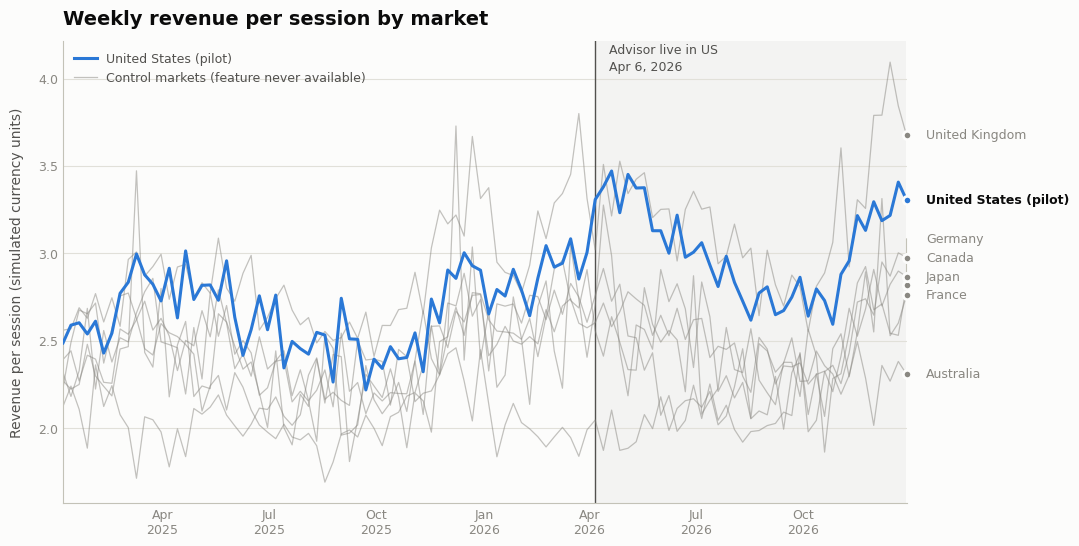

In [7]:
fig, ax = plot_rps_all_markets(df, savepath=str(FIGDIR / "rps_all_markets.png"))

The US does sit higher after launch. Before reading that as an effect, note two things
the chart alone does not separate.

In [8]:
us = df[df["market"] == PILOT].copy()
us["year"], us["month"] = us["week_start"].dt.year, us["week_start"].dt.month

seasonality = us.pivot_table(index="month", columns="year", values=METRIC).round(3)
seasonality.columns = [str(c) for c in seasonality.columns]
seasonality["yoy change"] = (seasonality["2026"] - seasonality["2025"]).round(3)
print("US revenue per session by month — 2025 is entirely pre-launch\n")
seasonality

US revenue per session by month — 2025 is entirely pre-launch



,2025,2026,yoy change
month,,,
1,2.554,2.778,0.224
2,2.589,2.834,0.245
3,2.852,2.961,0.109
4,2.824,3.348,0.524
5,2.831,3.333,0.502
6,2.587,3.067,0.480
7,2.514,2.947,0.433
8,2.442,2.752,0.310
9,2.475,2.734,0.259


**Seasonality.** In 2025, with no advisor anywhere, the US already climbed from 2.59 in
February to 2.85 in March and held ~2.83 through May. March–May is the market's seasonal
high. The advisor launched 6 April, straight into it.

**A pre-existing upward trend.** The US is up year-over-year in *every* month, including
January (+0.22) and February (+0.25) — both entirely before launch.

So part of the post-launch level is seasonal, part is a trend that predates the feature,
and part may be the feature. A before/after comparison cannot separate them. That is the
case for difference-in-differences.

---
## 3. What else was happening around launch? (finding F)

The launch week did not arrive alone.

In [9]:
context = ["paid_media_index", "promo_intensity", "new_visitor_share"]
window = us[us["week_index"].between(60, 70)][
    ["week_start", "week_index", METRIC, *context, "digital_feature_available"]
]
print("US, weeks either side of launch (digital_feature_available flips at week 65)\n")
window.round(4)

US, weeks either side of launch (digital_feature_available flips at week 65)



,week_start,week_index,revenue_per_session,paid_media_index,promo_intensity,new_visitor_share,digital_feature_available
684,2026-03-02,60,2.9215,100.18,0.2057,0.4562,0
685,2026-03-09,61,2.9437,110.05,0.2305,0.4358,0
686,2026-03-16,62,3.0833,110.13,0.2345,0.4155,0
687,2026-03-23,63,2.8532,104.50,0.2561,0.4509,0
688,2026-03-30,64,3.0053,126.85,0.2772,0.4845,0
689,2026-04-06,65,3.3078,133.86,0.3112,0.5028,1
690,2026-04-13,66,3.3808,136.13,0.3060,0.5018,1
691,2026-04-20,67,3.4711,128.87,0.2947,0.5076,1
692,2026-04-27,68,3.2325,119.17,0.2877,0.5018,1
693,2026-05-04,69,3.4516,130.65,0.2813,0.4841,1


In [10]:
pre8 = us[us["week_index"].between(57, 64)][context].mean()
post8 = us[us["week_index"].between(65, 72)][context].mean()
shift = pd.DataFrame({"8wk pre-launch": pre8, "8wk post-launch": post8})
shift["change"] = shift["8wk post-launch"] - shift["8wk pre-launch"]
shift["% change"] = (100 * shift["change"] / shift["8wk pre-launch"]).round(1)
shift.round(4)

,8wk pre-launch,8wk post-launch,change,% change
paid_media_index,110.6775,124.7425,14.0650,12.7
promo_intensity,0.2364,0.2815,0.0451,19.1
new_visitor_share,0.4390,0.4768,0.0379,8.6


**Paid media, promotional depth, and new-visitor share all jump at the same time as the
feature** — and `paid_media_index` starts climbing the week *before* launch, when the
advisor was not yet available.

This is the central complication. The post-launch rise in US revenue per session is a
media push, a promotional push, *and* the advisor, arriving together. No design can fully
separate them from this data alone; a DiD that ignores them will attribute all three to
the feature. They should enter the model as controls, and the limitation should be stated
plainly in the write-up.

---
## 4. Which market best approximates the untreated US?

DiD needs a control whose **pre-treatment trend** parallels the US. Two measures, on
pre-launch weeks only:

- `level_corr` — do the raw weekly series track each other?
- `delta_corr` — do the week-over-week *changes* move together? This is the one that
  speaks to parallel trends; levels can correlate on shared seasonality alone.
- `gap_sd` — volatility of the US-minus-market gap. Lower is steadier.

In [11]:
pre = df[df["week_start"] < LAUNCH]
wide = pre.pivot(index="week_start", columns="market", values=METRIC)
deltas = wide.diff()

similarity = pd.DataFrame([
    {
        "market": m,
        "level_corr": wide[PILOT].corr(wide[m]),
        "delta_corr": deltas[PILOT].corr(deltas[m]),
        "gap_sd": (wide[PILOT] - wide[m]).std(),
        "pre_mean_rps": wide[m].mean(),
    }
    for m in CONTROLS
]).sort_values("delta_corr", ascending=False).reset_index(drop=True)
similarity.round(4)

,market,level_corr,delta_corr,gap_sd,pre_mean_rps
0,Canada,0.8596,0.5892,0.1113,2.4461
1,France,0.5499,0.1093,0.2800,2.3911
2,Germany,0.6323,0.0318,0.2454,2.3682
3,Australia,-0.4449,-0.0783,0.3387,2.1230
4,United Kingdom,0.6369,-0.1622,0.2324,2.8679
5,Japan,0.5549,-0.2785,0.2210,2.4496


In [12]:
# The measures disagree past first place -- worth stating rather than hiding.
for measure, ascending in [("level_corr", False), ("delta_corr", False), ("gap_sd", True)]:
    ranked = similarity.sort_values(measure, ascending=ascending)["market"].tolist()
    print(f"top 3 by {measure:11s}: {ranked[:3]}")

top 3 by level_corr : ['Canada', 'United Kingdom', 'Germany']
top 3 by delta_corr : ['Canada', 'France', 'Germany']
top 3 by gap_sd     : ['Canada', 'Japan', 'United Kingdom']


**Canada is first on all three measures.** Positions 2 and 3 depend entirely on which
measure you pick, so the runners-up are best described as sensitivity checks rather than
a ranked list.

The gap is not marginal: on week-over-week changes Canada correlates with the US at
roughly 0.59, while every other market is at 0.11 or below — several are negative,
meaning their weekly movements run *opposite* to the US.

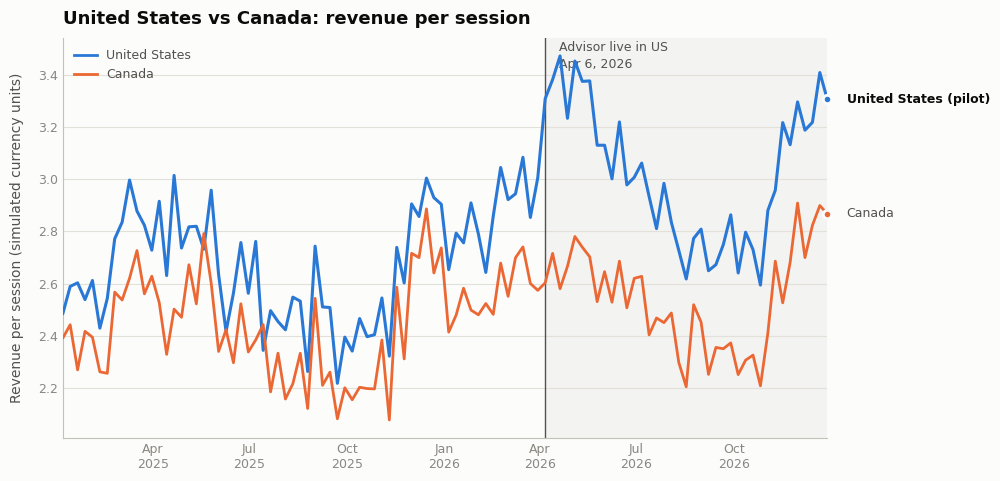

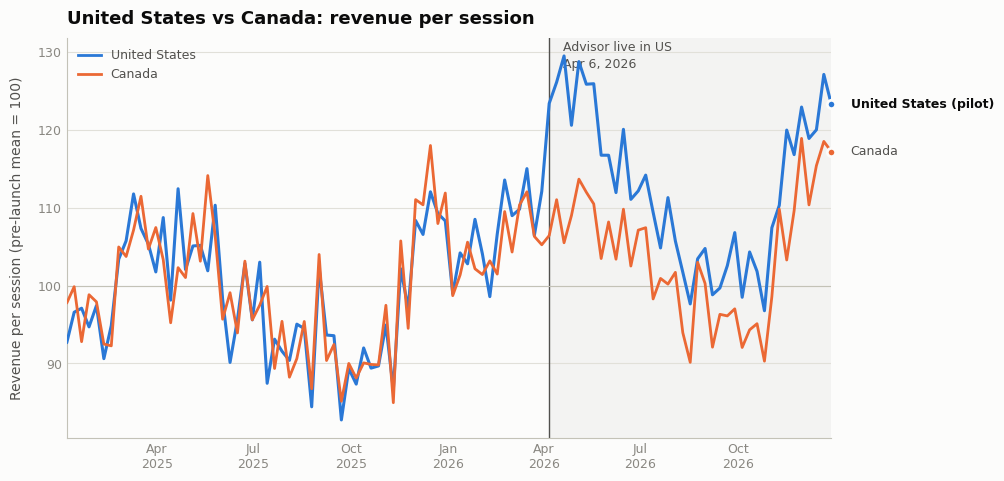

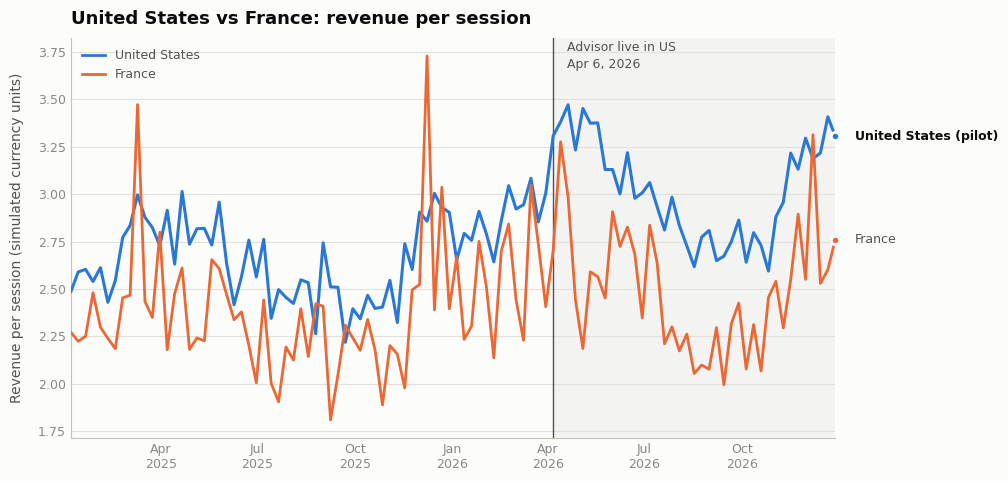

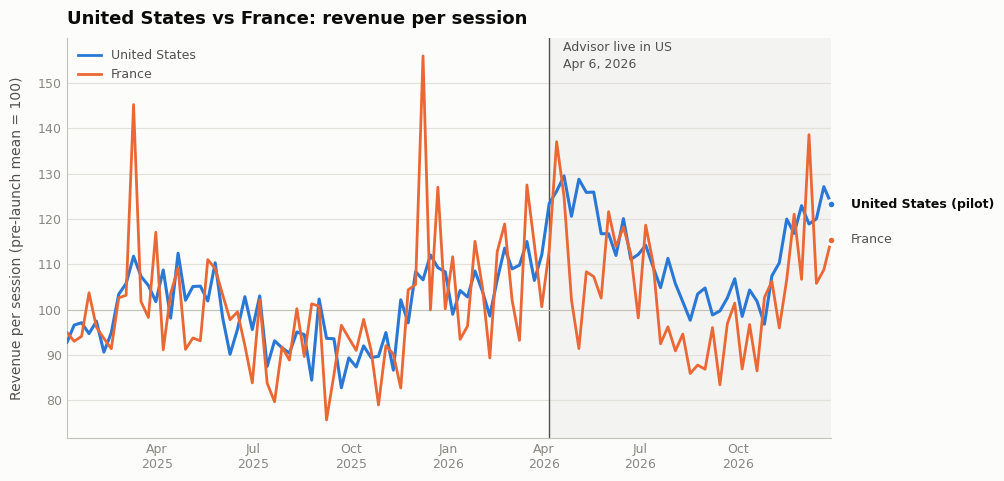

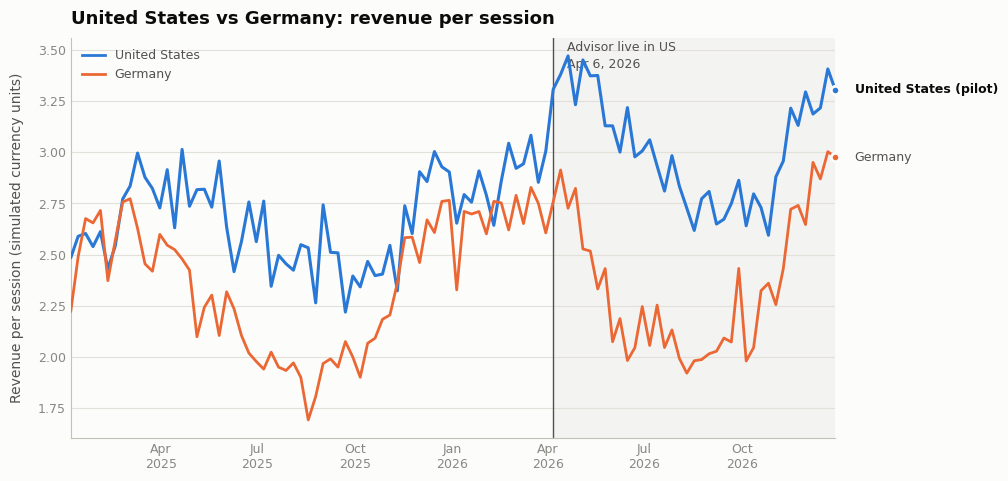

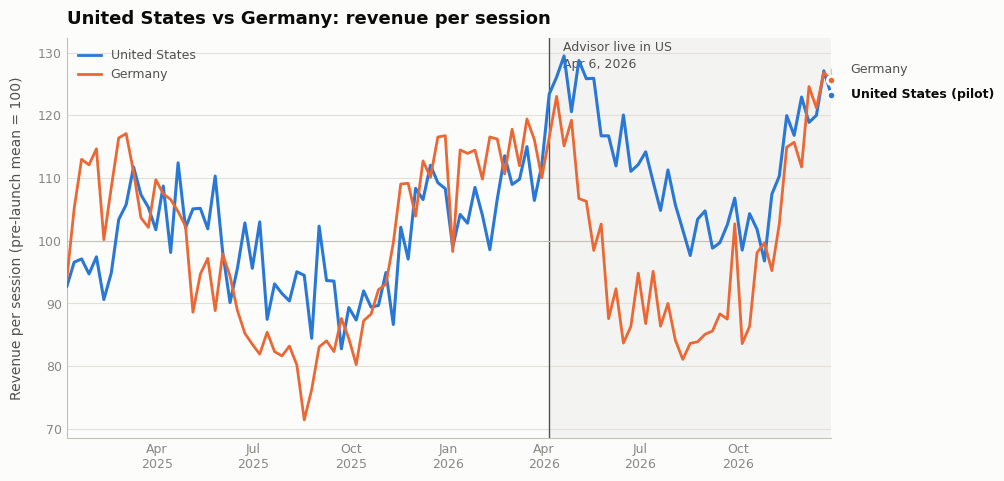

In [13]:
top3 = similarity.head(3)["market"].tolist()
for market in top3:
    slug = market.lower().replace(" ", "_")
    for view, indexed in [("levels", False), ("indexed", True)]:
        plot_rps_pairwise(df, market, index_to_pre=indexed,
                          savepath=str(FIGDIR / f"rps_us_vs_{slug}_{view}.png"))

Read the **levels** chart first — it is honest that the markets sit at different revenue
per session. Then the **indexed** chart, where each market is rebased to its own
pre-launch mean = 100: the level gap disappears and only the trends remain.

> ⚠️ Indexing is a claim about *percent* change, while a DiD fit on raw
> `revenue_per_session` assumes *absolute* parallel trends. If the indexed view is the
> parallel-trends argument, the model should be fit on `log(revenue_per_session)` to
> match, or a levels-based pre-trend check shown alongside.

---
## 5. Conclusion

**Canada is the strongest counterfactual for the United States.**

- It leads on all three pre-launch similarity measures — level correlation (0.86),
  week-over-week change correlation (0.59), and gap stability. No other market leads
  on any of them.
- The other five are weaker for different reasons. The **United Kingdom** looks close on
  raw levels (it is nearest the US in revenue per session) but its weekly *changes* run
  slightly opposite to the US, so it fails the test that matters. **France** and
  **Germany** co-move mildly but sit far from the US in level and are noisier.
  **Japan** is negatively correlated on changes. **Australia** is negatively correlated on
  levels and is the furthest from the US on every measure.
- Canada also arrived independently in the counterfactual and top-3 subtask analyses,
  which used different scoring methods.

**What this does not establish.** Canada being the best available control does not make
the parallel-trends assumption true — it makes it testable. And the media, promotion, and
new-visitor shifts in section 3 land in the same weeks as the feature, so any estimate
that omits them will credit the advisor with their effect too.

**Next:** a formal pre-trend test on the US–Canada pair, then a DiD with the launch-context
variables as controls.